## Program: TKEmodel
### Fit TKE, sig_w, and dissipation data into the model.

### Histories:
### 2024/10/04 -- Bicheng Chen (bchen@xmu.edu.cn) -- First created.

## 
---
---
## Prerequisite Module

In [1]:
import os
import pandas as pd
import numpy as np
from fractions import Fraction
from model.lsclib import caseClass, find_caseKey
from scipy import linalg
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import optimize as op
import xarray as xr

## 
---
---
## User-specified Variable

In [2]:
# File
path_data = "G:\LSCDynRegime_cxy\data"
bn_data = "statistics.feather"
fmt_key = "Lat{Lat:s}_X{X:s}_kH{kH:s}"

In [3]:
# Case
Laₜ_all = (0.35, 0.7, np.inf)
χ_all = (Fraction(1, 2), Fraction(3, 4), Fraction(1, 1), Fraction(4, 3), Fraction(2, 1))
kH_all = (Fraction(5, 2), Fraction(5, 1), Fraction(10, 1)) 
ustar_all = (0.01214, 0.00857, 0.00605) # m/s
H = 25 # m
κ = 0.012 # for tke32, kappa = 0.022 is the best
# κ = 0.01 # for w3
"""
ustar (m/s)  kH
0.01214      2.5/nan
0.00857      5.0
0.00605      10.0
"""

'\nustar (m/s)  kH\n0.01214      2.5/nan\n0.00857      5.0\n0.00605      10.0\n'

In [4]:
# Data
key_col = ["dissip+", "avg_u+"]
nz = 101
H = 25 # m
Δt = 120 # second
dz_nd = 1 / (nz - 1)

In [5]:
ustar_s=np.array([0.01214, 0.00857, 0.00605,
                 0.01214, 0.00857, 0.00605,
                 0.01214, 0.00857, 0.00605,
                 0.01214, 0.00857, 0.00605,
                 0.01214, 0.00857, 0.00605,
                 0.01214, 0.00857, 0.00605,
                 0.01214, 0.00857, 0.00605,
                 0.01214, 0.00857, 0.00605,
                 0.01214, 0.00857, 0.00605,
                 0.01214, 0.00857, 0.00605,
                 0.01214,0.01214,0.01214,0.01214,0.01214])#kH2.5 kH5 kH10
chi=np.array([0.5,0.5,0.5,
             0.75,0.75,0.75,
             1,1,1,
             4/3,4/3,4/3,
             2,2,2,
             0.5,0.5,0.5,
             0.75,0.75,0.75,
             1,1,1,
             4/3,4/3,4/3,
             2,2,2,
             0.5,0.75,1,4/3,2])
ustar_b=ustar_s/chi
ustar_s3=ustar_s**3
ustar_s2=ustar_s**2

##
---
---
### User-defined Function

In [6]:
# Calculate the first independent variable of the fitting formula
def cal_xs(Ub):
    return Ub**3

In [7]:
# Calculate the second independent variable of the fitting formula
def cal_xl(Ub, Us):
    xl = (Us-Ub)**3
    return xl

## 
---
---
### Read TKE data for each case

In [8]:
## Create case containers
case_all = dict()
for Laₜ in Laₜ_all:
    for χ in χ_all:
        if Laₜ == np.inf:
            case = caseClass(Laₜ, χ, 0, ustar_all[0], H)
            case_all[case.key_case] = case
        else:
            for ik, kH in enumerate(kH_all):
                case = caseClass(Laₜ, χ, kH, ustar_all[ik], H)
                case_all[case.key_case] = case

In [9]:
## Read all data
fmt_fn = os.path.join(path_data, "{case:s}", bn_data)
for i,case in enumerate(case_all):
    data_col = pd.read_feather(fmt_fn.format(case=case))[key_col]

    case_all[case].data = pd.DataFrame()
    case_all[case].data['dissip+'] = data_col['dissip+']
    case_all[case].data['avg_ub+'] = data_col['avg_u+'][50]
    case_all[case].data['avg_us+'] = data_col['avg_u+'][0]
    case_all[case].data['dissip+'] = data_col['dissip+']

    case_all[case].data = case_all[case].data.mean()
    case_all[case].data['avg_u+'] = data_col['avg_u+']

    
    case_all[case].data['avg_ub+'] *= ustar_s[i]
    case_all[case].data['avg_us+'] *= ustar_s[i]
    case_all[case].data['dissip+'] *= ustar_s3[i]
    #case_all[case].data['avg_u+'] *=ustar_s[i]

##
---
---
### Fitting data to derived models

In [10]:
## Re-organize data to array-type for fitting
# Declare data variable
ndim = len(case_all)
dissip_les = np.zeros(ndim)
ub = np.zeros(ndim)
us = np.zeros(ndim)
u = np.zeros((ndim,101))

# Extract data values from data containers
for ic, case in enumerate(case_all):
    dissip_les[ic] = case_all[case].data['dissip+']
    ub[ic] = case_all[case].data['avg_ub+']
    us[ic] = case_all[case].data['avg_us+']
    u[ic] = case_all[case].data['avg_u+']

In [11]:
Ub3=cal_xs(ub)
UL_Ub_3=cal_xl(ub,us)

In [12]:
## Do the linear fit for dissipation model
mat = np.hstack([(Ub3)[:, np.newaxis], (UL_Ub_3)[:, np.newaxis]])
coef_dissip, resid, rank, sigma = linalg.lstsq(mat, dissip_les)

SStot = ((dissip_les - dissip_les.mean())**2).sum()
SSres = ((dissip_les - np.dot(mat,coef_dissip))**2).sum()
R2_dissip = 1 - SSres / SStot

In [13]:
coef_dissip

array([0.00095974, 0.00384361])

In [14]:
R2_dissip

np.float64(0.9952716233482024)

In [15]:
dissip_fit=coef_dissip[0] * Ub3 + coef_dissip[1] * UL_Ub_3

In [16]:
data = np.array([[dissip_fit[0:3],dissip_fit[3:6],dissip_fit[6:9],dissip_fit[9:12],dissip_fit[12:15]],[dissip_fit[15:18],dissip_fit[18:21],dissip_fit[21:24],dissip_fit[24:27],dissip_fit[27:30]]])
data2 = np.array([[dissip_les[0:3],dissip_les[3:6],dissip_les[6:9],dissip_les[9:12],dissip_les[12:15]],[dissip_les[15:18],dissip_les[18:21],dissip_les[21:24],dissip_les[24:27],dissip_les[27:30]]])

da = xr.DataArray(data,dims=("Lat","chi","kH"), coords=[('Lat',[0.35, 0.7]),('chi',[0.5,0.75,1,4/3,2]),('kH',[2.5,5,10])])
da2 = xr.DataArray(data2,dims=("Lat","chi","kH"), coords=[('Lat',[0.35, 0.7]),('chi',[0.5,0.75,1,4/3,2]),('kH',[2.5,5,10])])

## 
---
---
### Show the fitting results

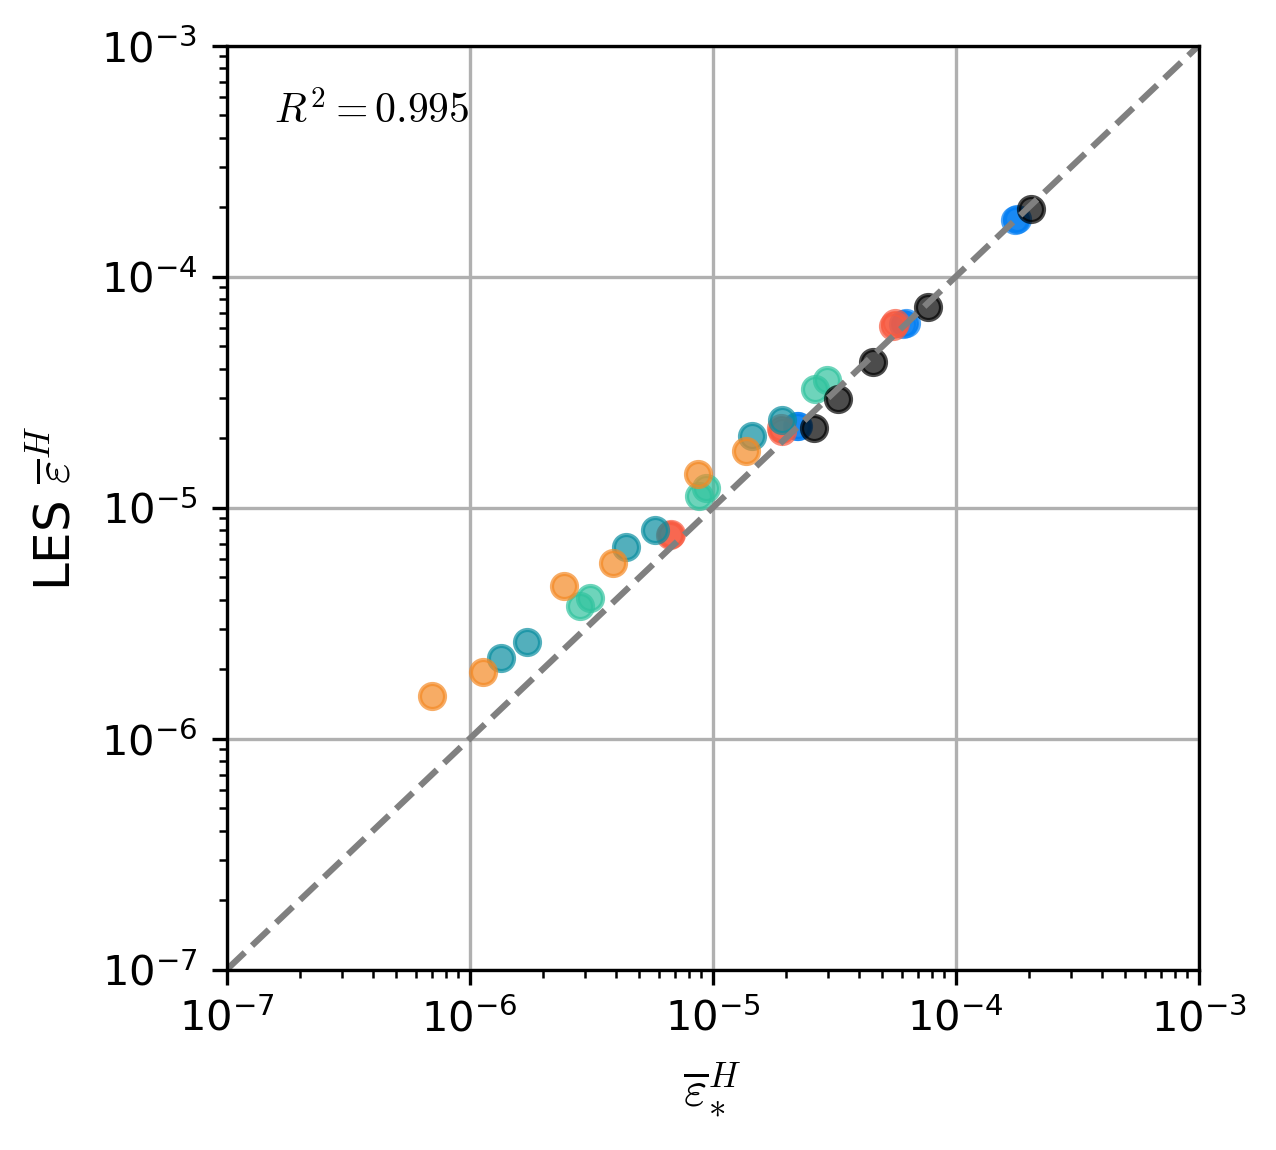

In [17]:
plt.rcParams['mathtext.fontset'] = 'cm'
ifig=0
fig=plt.figure(ifig,figsize=(4,4),dpi=300)
min=1e-7
max=1e-3

ax1=plt.subplot(111)
ax1.loglog(da.sel(kH=2.5,chi=0.5),da2.sel(kH=2.5,chi=0.5),linewidth =1.5, color='#037ef3',linestyle='none',alpha=0.7,marker='o',label='$kH=2.5$'+','+'$\chi=0.5$')# #49beb7 #ff5959
ax1.loglog(da.sel(kH=5,chi=0.5),da2.sel(kH=5,chi=0.5),linewidth =1.5, color='#037ef3',linestyle='none',alpha=0.7,marker='o',label='$kH=5$'+','+'$\chi=0.5$')
ax1.loglog(da.sel(kH=10,chi=0.5),da2.sel(kH=10,chi=0.5),linewidth =1.5, color='#037ef3',linestyle='none',alpha=0.7,marker='o',label='$kH=10$'+','+'$\chi=0.5$')

ax1.loglog(da.sel(kH=2.5,chi=0.75),da2.sel(kH=2.5,chi=0.75),linewidth =1.5, color='#f85a40',linestyle='none',alpha=0.7,marker='o',label='$kH=2.5$'+','+'$\chi=0.75$')
ax1.loglog(da.sel(kH=5,chi=0.75),da2.sel(kH=5,chi=0.75),linewidth =1.5, color='#f85a40',linestyle='none',alpha=0.7,marker='o',label='$kH=5$'+','+'$\chi=0.75$')
ax1.loglog(da.sel(kH=10,chi=0.75),da2.sel(kH=10,chi=0.75),linewidth =1.5, color='#f85a40',linestyle='none',alpha=0.7,marker='o',label='$kH=10$'+','+'$\chi=0.75$')

ax1.loglog(da.sel(kH=2.5,chi=1),da2.sel(kH=2.5,chi=1),linewidth =1.5, color='#30c39e',linestyle='none',alpha=0.7,marker='o',label='$kH=2.5$'+','+'$\chi=1$')
ax1.loglog(da.sel(kH=5,chi=1),da2.sel(kH=5,chi=1),linewidth =1.5, color='#30c39e',linestyle='none',alpha=0.7,marker='o',label='$kH=5$'+','+'$\chi=1$')
ax1.loglog(da.sel(kH=10,chi=1),da2.sel(kH=10,chi=1),linewidth =1.5, color='#30c39e',linestyle='none',alpha=0.7,marker='o',label='$kH=10$'+','+'$\chi=1$')


ax1.loglog(da.sel(kH=2.5,chi=4/3),da2.sel(kH=2.5,chi=4/3),linewidth =1.5, color='#0a8ea0',linestyle='none',alpha=0.7,marker='o',label='$kH=2.5$'+','+'$\chi=4/3$')
ax1.loglog(da.sel(kH=5,chi=4/3),da2.sel(kH=5,chi=4/3),linewidth =1.5, color='#0a8ea0',linestyle='none',alpha=0.7,marker='o',label='$kH=5$'+','+'$\chi=4/3$')
ax1.loglog(da.sel(kH=10,chi=4/3),da2.sel(kH=10,chi=4/3),linewidth =1.5, color='#0a8ea0',linestyle='none',alpha=0.7,marker='o',label='$kH=10$'+','+'$\chi=4/3$')

ax1.loglog(da.sel(kH=2.5,chi=2),da2.sel(kH=2.5,chi=2),linewidth =1.5, color='#f48924',linestyle='none',alpha=0.7,marker='o',label='$kH=2.5$'+','+'$\chi=2$')
ax1.loglog(da.sel(kH=5,chi=2),da2.sel(kH=5,chi=2),linewidth =1.5, color='#f48924',linestyle='none',alpha=0.7,marker='o',label='$kH=5$'+','+'$\chi=2$')
ax1.loglog(da.sel(kH=10,chi=2),da2.sel(kH=10,chi=2),linewidth =1.5, color='#f48924',linestyle='none',alpha=0.7,marker='o',label='$kH=10$'+','+'$\chi=2$')

ax1.loglog(dissip_fit[30:35],dissip_les[30:35],linewidth =1.5, color='k',linestyle='none',alpha=0.7,marker='o',label='$La_t=\infty$')

diag_line = ax1.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax1.set_ylim([min,max])
ax1.set_xlim([min,max])
ax1.set_xlabel(r'$\overline{\varepsilon}_{*}^{H}$',fontsize=12,labelpad=5)
ax1.set_ylabel(r'LES $\overline{\varepsilon}^{H}$',fontsize=12,labelpad=5)

ax1.text(0.25, 0.95, "$R^2={:5.3f}$".format(R2_dissip),
            transform=ax1.transAxes, ha='right', va='top')
# plt.legend(loc='upper right')
#plt.legend(bbox_to_anchor=(1.05, 0.05), loc=3, borderaxespad=0)

ax1.grid(True)
fig.subplots_adjust(
    left=0.16,
    right=0.97,
    bottom=0.20,
    top=0.97
)
fig.savefig('epsion_practicalmodel_vs_les_H',bbox_inches='tight')
plt.show()


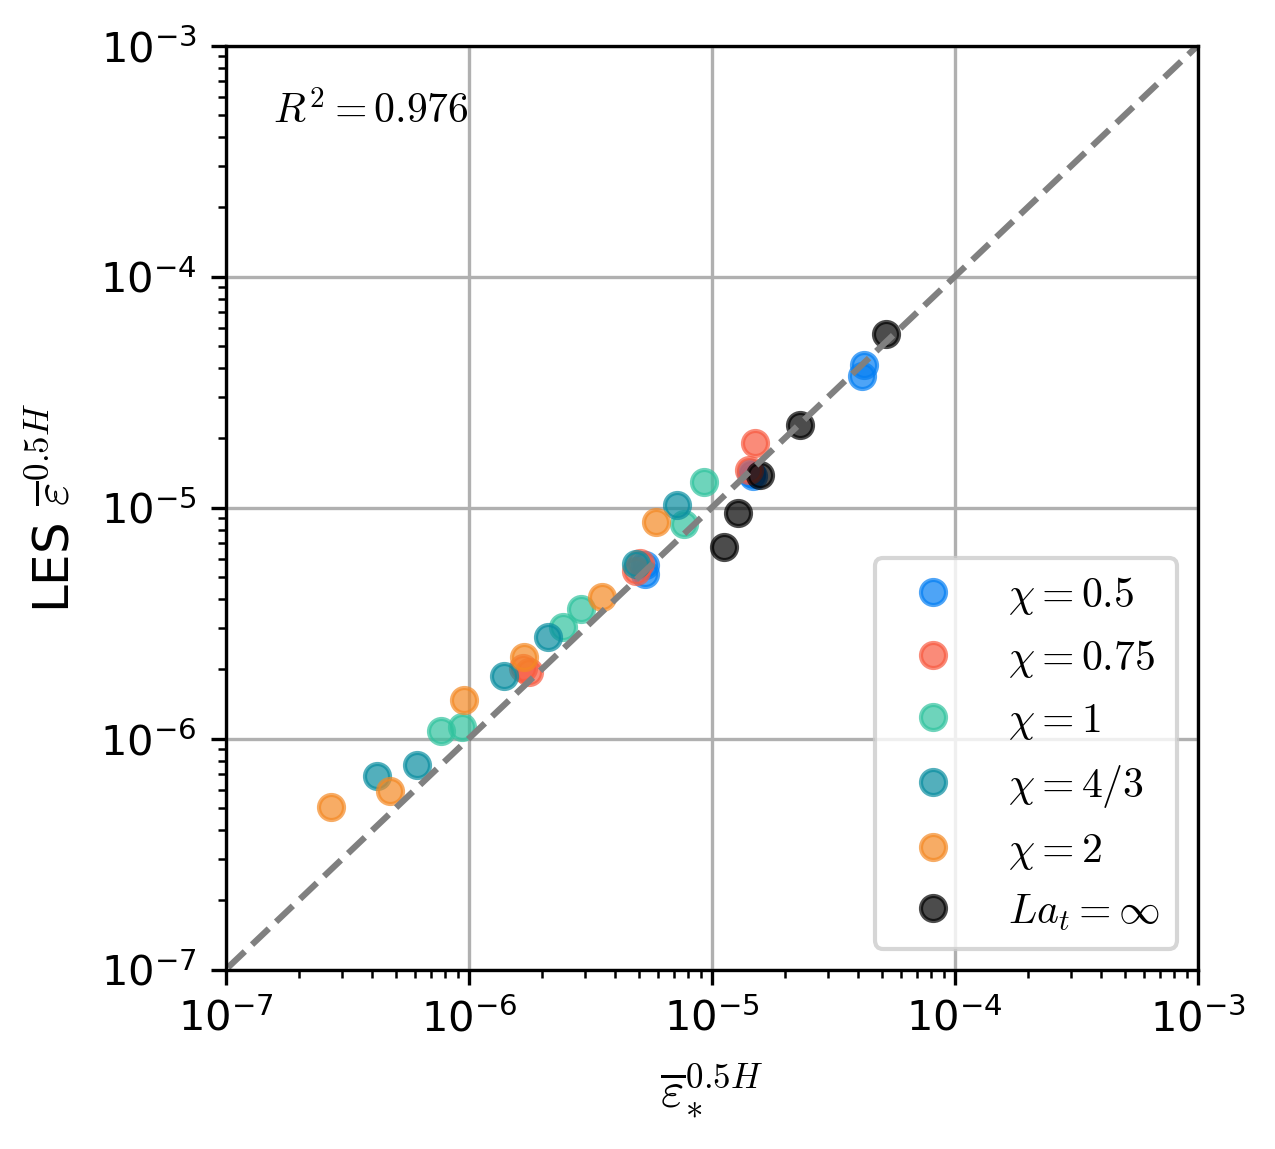

In [57]:
#按chi设置图例
plt.rcParams['mathtext.fontset'] = 'cm'
ifig=0
fig=plt.figure(ifig,figsize=(4,4),dpi=300)
min=1e-7
max=1e-3

ax1=plt.subplot(111)
ax1.loglog(da.sel(chi=0.5).data.flatten(),da2.sel(chi=0.5).data.flatten(),color='#037ef3',linestyle='none',alpha=0.7,marker='o',label='$\chi=0.5$')# #49beb7 #ff5959
ax1.loglog(da.sel(chi=0.75).data.flatten(),da2.sel(chi=0.75).data.flatten(), color='#f85a40',linestyle='none',alpha=0.7,marker='o',label='$\chi=0.75$')
ax1.loglog(da.sel(chi=1).data.flatten(),da2.sel(chi=1).data.flatten(),color='#30c39e',linestyle='none',alpha=0.7,marker='o',label='$\chi=1$')
ax1.loglog(da.sel(chi=4/3).data.flatten(),da2.sel(chi=4/3).data.flatten(),color='#0a8ea0',linestyle='none',alpha=0.7,marker='o',label='$\chi=4/3$')
ax1.loglog(da.sel(chi=2).data.flatten(),da2.sel(chi=2).data.flatten(), color='#f48924',linestyle='none',alpha=0.7,marker='o',label='$\chi=2$')
ax1.loglog(dissip_fit[30:35],dissip_les[30:35],color='k',linestyle='none',alpha=0.7,marker='o',label='$La_t=\infty$')

diag_line = ax1.plot([0, 1], [0, 1], color='gray', linestyle='--')
ax1.set_ylim([min,max])
ax1.set_xlim([min,max])
ax1.set_xlabel(r'$\overline{\varepsilon}_{*}^{0.5H}$',fontsize=12,labelpad=5)
ax1.set_ylabel(r'LES $\overline{\varepsilon}^{0.5H}$',fontsize=12,labelpad=5)

ax1.text(0.25, 0.95, "$R^2={:5.3f}$".format(R2_dissip),
            transform=ax1.transAxes, ha='right', va='top')
plt.legend(loc='lower right')
#plt.legend(bbox_to_anchor=(1.05, 0.05), loc=3, borderaxespad=0)

ax1.grid(True)
fig.subplots_adjust(
    left=0.16,
    right=0.97,
    bottom=0.2,
    top=0.97
)
fig.savefig('epsion_practicalmodel_vs_les_05H',bbox_inches='tight',dpi=300)
plt.show()
